In [1]:
import json

import logomaker as lm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyliftover
import seaborn as sns
from pyfaidx import Fasta
from scipy.stats import chi2_contingency

from analysis_functions import (
                        calculate_chi2_p_values,
                        filter_and_convert_to_list,
                        check_ref,
                        get_codon_info,
                        get_context
                    )

## 1. Separate variants by pathogenicity value

Create dataframes for pathogenic/benign variants based on frequency.

* **pathogenic**  
 Cutoff in AC < 2. Additionally, intersect with the options in ClinVar and add pathogenic/likely pathogenic variants that are missing in GnomAD v.4, but are in ClinVar.

* **benign**  
 AC cut-off >= 2 (according to recent ACGS guidelines, BS2 criterion). In this case, we may have many autosomal recessive variants left, so let’s remove them. To do this, compare the resulting dataframe with benign ClinVar variants and remove all intersections with registered P/LP variants.

In [2]:
nmd_escape_df = pd.read_csv("data/lof_final_with_loeuf_pext_nmd_escape.csv")

In [3]:
nmd_escape_df.shape

(4426, 31)

In [4]:
nmd_escape_df['BIOTYPE'].value_counts()

BIOTYPE
protein_coding    4426
Name: count, dtype: int64

In [5]:
pat_nmd_escape = nmd_escape_df.query('AC < 2')

In [6]:
pat_nmd_escape

,CHROM,POS,ID,REF,ALT,AC,Consequence,IMPACT,SYMBOL,Gene,...,FLAGS,VARIANT_CLASS,CANONICAL,LoF,LoF_filter,LoF_flags,LoF_info,LOEUF,pext,NMD_escape
1,chr1,2306243,rs1306616273,C,A,1,stop_gained,HIGH,SKI,ENSG00000157933,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.910379515317787,0.194,0.950938,YES
2,chr1,2306688,NaN,G,T,1,stop_gained,HIGH,SKI,ENSG00000157933,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.964791952446273,0.194,0.950938,YES
4,chr1,2306700,NaN,C,T,1,stop_gained,HIGH,SKI,ENSG00000157933,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.970278920896205,0.194,0.950938,YES
5,chr1,2306707,NaN,G,A,1,stop_gained,HIGH,SKI,ENSG00000157933,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.973479652491998,0.194,0.950938,YES
6,chr1,2306724,NaN,G,T,1,stop_gained,HIGH,SKI,ENSG00000157933,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.981252857796068,0.194,0.950938,YES
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4421,chr22,50275727,NaN,C,A,1,stop_gained,HIGH,PLXNB2,ENSG00000196576,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.995831067609208,0.285,1.000000,YES
4422,chr22,50447351,rs1556415963,T,A,1,stop_gained,HIGH,SBF1,ENSG00000100241,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.977472720872932,0.265,0.771752,YES
4423,chr22,50610725,NaN,C,G,1,stop_gained,HIGH,MAPK8IP2,ENSG00000008735,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.978181818181818,0.100,1.000000,YES
4424,chr22,50610732,NaN,G,T,1,stop_gained,HIGH,MAPK8IP2,ENSG00000008735,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.981010101010101,0.100,1.000000,YES


In [7]:
ben_nmd_escape = nmd_escape_df.query('AC >= 2')

In [8]:
ben_nmd_escape

,CHROM,POS,ID,REF,ALT,AC,Consequence,IMPACT,SYMBOL,Gene,...,FLAGS,VARIANT_CLASS,CANONICAL,LoF,LoF_filter,LoF_flags,LoF_info,LOEUF,pext,NMD_escape
0,chr1,2030133,NaN,G,T,7,stop_gained,HIGH,GABRD,ENSG00000187730,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.890360559234731,0.245,1.000000,YES
3,chr1,2306694,rs1375460797,C,T,3,stop_gained,HIGH,SKI,ENSG00000157933,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.967535436671239,0.194,0.950938,YES
11,chr1,6264626,rs745847219,G,A,15,stop_gained,HIGH,ACOT7,ENSG00000097021,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.973944294699012,0.193,0.994284,YES
12,chr1,9726957,rs1649753771,C,T,4,stop_gained,HIGH,PIK3CD,ENSG00000171608,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.971610845295056,0.196,0.855224,YES
15,chr1,9730654,NaN,C,A,6,stop_gained,HIGH,CLSTN1,ENSG00000171603,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.950441276306857,0.308,0.592226,YES
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4402,chr22,41178498,rs1354580969,C,T,3,stop_gained,HIGH,EP300,ENSG00000100393,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.936783988957902,0.099,1.000000,YES
4408,chr22,41178823,rs139208187,C,G,2,stop_gained,HIGH,EP300,ENSG00000100393,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.981642512077295,0.099,1.000000,YES
4410,chr22,41178931,rs1424813619,C,G,4,stop_gained,HIGH,EP300,ENSG00000100393,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.996549344375431,0.099,1.000000,YES
4413,chr22,41357424,NaN,G,T,2,stop_gained,HIGH,ZC3H7B,ENSG00000100403,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.998295841854124,0.323,0.988884,YES


In [9]:
ben_nmd_escape.columns

Index(['CHROM', 'POS', 'ID', 'REF', 'ALT', 'AC', 'Consequence', 'IMPACT',
       'SYMBOL', 'Gene', 'Feature', 'BIOTYPE', 'EXON', 'INTRON',
       'cDNA_position', 'CDS_position', 'Protein_position', 'Amino_acids',
       'Codons', 'ALLELE_NUM', 'STRAND', 'FLAGS', 'VARIANT_CLASS', 'CANONICAL',
       'LoF', 'LoF_filter', 'LoF_flags', 'LoF_info', 'LOEUF', 'pext',
       'NMD_escape'],
      dtype='object')

In [10]:
pat_nmd_escape['AC'].value_counts()  # 1

AC
1    3105
Name: count, dtype: int64

In [11]:
ben_nmd_escape['AC'].value_counts()  # from 2 to ~

AC
2      587
3      212
4      142
5       87
6       58
      ... 
22       1
101      1
26       1
236      1
79       1
Name: count, Length: 62, dtype: int64

In [12]:
ben_nmd_escape['AC'].describe()

count    1321.000000
mean       14.320212
std       260.140981
min         2.000000
25%         2.000000
50%         3.000000
75%         5.000000
max      9426.000000
Name: AC, dtype: float64

### Remove all pathogenic Clinvar variants from benign dataframe

Merge `clinvar_nmd_esc_df` and `ben_nmd_escape` dataframes, remove all intersections by `CHROM`, `POS`, `REF`, `ALT`, and then remove the remainder of `clinvar_nmd_esc_df` (i.e. remove all rows that do not have an empty `CLNSIG` column).

In [13]:
clinvar_nmd_esc_df = pd.read_csv("data/clinvar_nmd_escape_df.csv")
# clinvar_nmd_esc = clinvar_nmd_esc_df.rename(columns={'Feature': 'Canonical_transcript'})

In [14]:
clinvar_nmd_esc_df

,CHROM,POS,ID,REF,ALT,CLNREVSTAT,CLNSIG,CLNVC,GENEINFO,MC,...,CDS_position,Protein_position,Amino_acids,Codons,STRAND,FLAGS,CANONICAL,LOEUF,pext,NMD_escape
0,chr1,12009699,2682761,C,A,"criteria_provided,_single_submitter",Likely_pathogenic,single_nucleotide_variant,MFN2:9927,SO:0001587|nonsense,...,2177.0,726.0,S/*,tCa/tAa,1.0,NaN,YES,0.282,0.971272,YES
1,chr1,12009699,933991,C,G,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,MFN2:9927,SO:0001587|nonsense,...,2177.0,726.0,S/*,tCa/tGa,1.0,NaN,YES,0.282,0.971272,YES
2,chr1,12011511,1172816,G,A,"criteria_provided,_single_submitter",Likely_pathogenic,single_nucleotide_variant,MFN2:9927,SO:0001587|nonsense,...,2220.0,740.0,W/*,tgG/tgA,1.0,NaN,YES,0.282,0.971272,YES
3,chr1,12011542,572169,C,T,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic,single_nucleotide_variant,MFN2:9927,SO:0001587|nonsense,...,2251.0,751.0,Q/*,Cag/Tag,1.0,NaN,YES,0.282,0.971272,YES
4,chr1,12011547,217162,C,A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic,single_nucleotide_variant,MFN2:9927,SO:0001587|nonsense,...,2256.0,752.0,Y/*,taC/taA,1.0,NaN,YES,0.282,0.971272,YES
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1223,chr22,41178165,2572086,C,T,"criteria_provided,_single_submitter",Likely_pathogenic,single_nucleotide_variant,EP300:2033,SO:0001587|nonsense,...,6454.0,2152.0,Q/*,Cag/Tag,1.0,NaN,YES,0.099,1.000000,YES
1224,chr22,41178243,2653214,C,T,"criteria_provided,_single_submitter",Likely_pathogenic,single_nucleotide_variant,EP300:2033,SO:0001587|nonsense,...,6532.0,2178.0,Q/*,Caa/Taa,1.0,NaN,YES,0.099,1.000000,YES
1225,chr22,41178498,2978296,C,T,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,single_nucleotide_variant,EP300:2033,SO:0001587|nonsense,...,6787.0,2263.0,R/*,Cga/Tga,1.0,NaN,YES,0.099,1.000000,YES
1226,chr22,41178579,451064,C,T,"criteria_provided,_single_submitter",Likely_pathogenic,single_nucleotide_variant,EP300:2033,SO:0001587|nonsense,...,6868.0,2290.0,Q/*,Cag/Tag,1.0,NaN,YES,0.099,1.000000,YES


In [15]:
clinvar_nmd_esc_df.columns

Index(['CHROM', 'POS', 'ID', 'REF', 'ALT', 'CLNREVSTAT', 'CLNSIG', 'CLNVC',
       'GENEINFO', 'MC', 'Consequence', 'SYMBOL', 'Gene', 'Feature_type',
       'Feature', 'BIOTYPE', 'cDNA_position', 'CDS_position',
       'Protein_position', 'Amino_acids', 'Codons', 'STRAND', 'FLAGS',
       'CANONICAL', 'LOEUF', 'pext', 'NMD_escape'],
      dtype='object')

In [16]:
merged_clinvar_and_ben = pd.concat([ben_nmd_escape, clinvar_nmd_esc_df], ignore_index=True)
merged_clinvar_and_ben

,CHROM,POS,ID,REF,ALT,AC,Consequence,IMPACT,SYMBOL,Gene,...,LoF_info,LOEUF,pext,NMD_escape,CLNREVSTAT,CLNSIG,CLNVC,GENEINFO,MC,Feature_type
0,chr1,2030133,NaN,G,T,7.0,stop_gained,HIGH,GABRD,ENSG00000187730,...,PERCENTILE:0.890360559234731,0.245,1.000000,YES,NaN,NaN,NaN,NaN,NaN,NaN
1,chr1,2306694,rs1375460797,C,T,3.0,stop_gained,HIGH,SKI,ENSG00000157933,...,PERCENTILE:0.967535436671239,0.194,0.950938,YES,NaN,NaN,NaN,NaN,NaN,NaN
2,chr1,6264626,rs745847219,G,A,15.0,stop_gained,HIGH,ACOT7,ENSG00000097021,...,PERCENTILE:0.973944294699012,0.193,0.994284,YES,NaN,NaN,NaN,NaN,NaN,NaN
3,chr1,9726957,rs1649753771,C,T,4.0,stop_gained,HIGH,PIK3CD,ENSG00000171608,...,PERCENTILE:0.971610845295056,0.196,0.855224,YES,NaN,NaN,NaN,NaN,NaN,NaN
4,chr1,9730654,NaN,C,A,6.0,stop_gained,HIGH,CLSTN1,ENSG00000171603,...,PERCENTILE:0.950441276306857,0.308,0.592226,YES,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2544,chr22,41178165,2572086,C,T,NaN,stop_gained,NaN,EP300,ENSG00000100393,...,NaN,0.099,1.000000,YES,"criteria_provided,_single_submitter",Likely_pathogenic,single_nucleotide_variant,EP300:2033,SO:0001587|nonsense,Transcript
2545,chr22,41178243,2653214,C,T,NaN,stop_gained,NaN,EP300,ENSG00000100393,...,NaN,0.099,1.000000,YES,"criteria_provided,_single_submitter",Likely_pathogenic,single_nucleotide_variant,EP300:2033,SO:0001587|nonsense,Transcript
2546,chr22,41178498,2978296,C,T,NaN,stop_gained,NaN,EP300,ENSG00000100393,...,NaN,0.099,1.000000,YES,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,single_nucleotide_variant,EP300:2033,SO:0001587|nonsense,Transcript
2547,chr22,41178579,451064,C,T,NaN,stop_gained,NaN,EP300,ENSG00000100393,...,NaN,0.099,1.000000,YES,"criteria_provided,_single_submitter",Likely_pathogenic,single_nucleotide_variant,EP300:2033,SO:0001587|nonsense,Transcript


In [17]:
merged_clinvar_and_ben.columns

Index(['CHROM', 'POS', 'ID', 'REF', 'ALT', 'AC', 'Consequence', 'IMPACT',
       'SYMBOL', 'Gene', 'Feature', 'BIOTYPE', 'EXON', 'INTRON',
       'cDNA_position', 'CDS_position', 'Protein_position', 'Amino_acids',
       'Codons', 'ALLELE_NUM', 'STRAND', 'FLAGS', 'VARIANT_CLASS', 'CANONICAL',
       'LoF', 'LoF_filter', 'LoF_flags', 'LoF_info', 'LOEUF', 'pext',
       'NMD_escape', 'CLNREVSTAT', 'CLNSIG', 'CLNVC', 'GENEINFO', 'MC',
       'Feature_type'],
      dtype='object')

In [18]:
# remove duplicates
ben_nmd_escape_filtered = merged_clinvar_and_ben.drop_duplicates(subset=['CHROM', 'POS', 'REF', 'ALT'], keep=False)

In [19]:
# remove the Clinvar df
ben_nmd_escape_filtered = ben_nmd_escape_filtered[~ben_nmd_escape_filtered['CLNSIG'].notna()]

In [20]:
ben_nmd_escape_filtered.columns

Index(['CHROM', 'POS', 'ID', 'REF', 'ALT', 'AC', 'Consequence', 'IMPACT',
       'SYMBOL', 'Gene', 'Feature', 'BIOTYPE', 'EXON', 'INTRON',
       'cDNA_position', 'CDS_position', 'Protein_position', 'Amino_acids',
       'Codons', 'ALLELE_NUM', 'STRAND', 'FLAGS', 'VARIANT_CLASS', 'CANONICAL',
       'LoF', 'LoF_filter', 'LoF_flags', 'LoF_info', 'LOEUF', 'pext',
       'NMD_escape', 'CLNREVSTAT', 'CLNSIG', 'CLNVC', 'GENEINFO', 'MC',
       'Feature_type'],
      dtype='object')

In [21]:
pat_nmd_escape.columns

Index(['CHROM', 'POS', 'ID', 'REF', 'ALT', 'AC', 'Consequence', 'IMPACT',
       'SYMBOL', 'Gene', 'Feature', 'BIOTYPE', 'EXON', 'INTRON',
       'cDNA_position', 'CDS_position', 'Protein_position', 'Amino_acids',
       'Codons', 'ALLELE_NUM', 'STRAND', 'FLAGS', 'VARIANT_CLASS', 'CANONICAL',
       'LoF', 'LoF_filter', 'LoF_flags', 'LoF_info', 'LOEUF', 'pext',
       'NMD_escape'],
      dtype='object')

Remove unnecessary columns left after Clinvar.

In [22]:
# ben_nmd_escape_filtered = ben_nmd_escape_filtered.drop(columns=['ID', 'CLNSIG', 'CLNVC', 'GENEINFO', 'CLNREVSTAT', 'MC', 'SYMBOL', 
#                                                 'Gene', 'Feature_type', 'BIOTYPE', 'CANONICAL'])
ben_nmd_escape_filtered = ben_nmd_escape_filtered.drop(columns=['CLNSIG', 'CLNVC', 'GENEINFO', 'MC', 'CLNREVSTAT', 'Feature_type'])
ben_nmd_escape_filtered

,CHROM,POS,ID,REF,ALT,AC,Consequence,IMPACT,SYMBOL,Gene,...,FLAGS,VARIANT_CLASS,CANONICAL,LoF,LoF_filter,LoF_flags,LoF_info,LOEUF,pext,NMD_escape
0,chr1,2030133,NaN,G,T,7.0,stop_gained,HIGH,GABRD,ENSG00000187730,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.890360559234731,0.245,1.000000,YES
1,chr1,2306694,rs1375460797,C,T,3.0,stop_gained,HIGH,SKI,ENSG00000157933,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.967535436671239,0.194,0.950938,YES
2,chr1,6264626,rs745847219,G,A,15.0,stop_gained,HIGH,ACOT7,ENSG00000097021,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.973944294699012,0.193,0.994284,YES
3,chr1,9726957,rs1649753771,C,T,4.0,stop_gained,HIGH,PIK3CD,ENSG00000171608,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.971610845295056,0.196,0.855224,YES
4,chr1,9730654,NaN,C,A,6.0,stop_gained,HIGH,CLSTN1,ENSG00000171603,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.950441276306857,0.308,0.592226,YES
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1315,chr22,41178264,NaN,C,T,3.0,stop_gained,HIGH,EP300,ENSG00000100393,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.904485852311939,0.099,1.000000,YES
1317,chr22,41178823,rs139208187,C,G,2.0,stop_gained,HIGH,EP300,ENSG00000100393,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.981642512077295,0.099,1.000000,YES
1318,chr22,41178931,rs1424813619,C,G,4.0,stop_gained,HIGH,EP300,ENSG00000100393,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.996549344375431,0.099,1.000000,YES
1319,chr22,41357424,NaN,G,T,2.0,stop_gained,HIGH,ZC3H7B,ENSG00000100403,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.998295841854124,0.323,0.988884,YES


In [23]:
ben_nmd_escape_filtered.columns == pat_nmd_escape.columns

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True])

In [24]:
ben_nmd_escape_filtered.shape

(1290, 31)

Before filtering:

In [25]:
ben_nmd_escape.shape

(1321, 31)

**The dataframe with benign variants is ready.**

In [26]:
pat_nmd_escape_filtered = pat_nmd_escape.copy()

**The dataframe with pathogenic variants is ready.**

## 2. Balance dataframes

In both dataframes, we will leave only those genes that are found in both `ben_nmd_escape_filtered` and `pat_nmd_escape_filtered`, and also equalize the number of variants in each gene.

In [27]:
unique_genes_ben = ben_nmd_escape_filtered['SYMBOL'].unique()
unique_genes_pat = pat_nmd_escape_filtered['SYMBOL'].unique()
intersected_genes = np.intersect1d(unique_genes_pat, unique_genes_ben)

print("Unique genes in pat dataframe:", len(unique_genes_pat))
print("Unique genes in ben dataframe:", len(unique_genes_ben))
print("Intersected genes:", len(intersected_genes))


Unique genes in pat dataframe: 1183
Unique genes in ben dataframe: 758
Intersected genes: 560


In [28]:
common_genes = set(unique_genes_ben) & set(unique_genes_pat)

ben_nmd_escape_filtered = ben_nmd_escape_filtered[ben_nmd_escape_filtered['SYMBOL'].isin(common_genes)]
pat_nmd_escape_filtered = pat_nmd_escape_filtered[pat_nmd_escape_filtered['SYMBOL'].isin(common_genes)]

In [29]:
unique_genes_pat = pat_nmd_escape_filtered['SYMBOL'].unique()
unique_genes_ben = ben_nmd_escape_filtered['SYMBOL'].unique()

intersected_genes = np.intersect1d(unique_genes_pat, unique_genes_ben)

print("Unique genes in pat dataframe:", len(unique_genes_pat))
print("Unique genes in ben dataframe:", len(unique_genes_ben))
print("Intersected genes:", len(intersected_genes))

Unique genes in pat dataframe: 560
Unique genes in ben dataframe: 560
Intersected genes: 560


In [30]:
count_pat = pat_nmd_escape_filtered['SYMBOL'].value_counts()
count_ben = ben_nmd_escape_filtered['SYMBOL'].value_counts()

min_counts = pd.concat([count_pat, count_ben], axis=1).min(axis=1)

pat_nmd_escape_final = pd.concat([
    pat_nmd_escape_filtered[pat_nmd_escape_filtered['SYMBOL'] == gene].sample(n=min_count, random_state=42) \
    for gene, min_count in min_counts.items()
])

ben_nmd_escape_final = pd.concat([
    ben_nmd_escape_filtered[ben_nmd_escape_filtered['SYMBOL'] == gene].sample(n=min_count, random_state=42) \
    for gene, min_count in min_counts.items()
])


In [31]:
pat_nmd_escape_final.shape == ben_nmd_escape_final.shape

True

In [32]:
pat_nmd_escape_final.shape

(926, 31)

In [33]:
ben_nmd_escape_final.shape

(926, 31)

In [34]:
pat_nmd_escape_final['SYMBOL'].nunique() == ben_nmd_escape_final['SYMBOL'].nunique()

True

In [35]:
pat_nmd_escape_final['SYMBOL'].value_counts().sum() == ben_nmd_escape_final['SYMBOL'].value_counts().sum()

np.True_

In [36]:
pat_nmd_escape_final['SYMBOL'].nunique()

560

In [37]:
ben_nmd_escape_final['SYMBOL'].nunique()

560

In [38]:
pat_nmd_escape_final.shape

(926, 31)

In [39]:
ben_nmd_escape_final.shape

(926, 31)

Dataframes are now balanced by genes and number of variants.

## 3. Get sequence context

Write the context in the corresponding column of the dataframe.

File `gencode.v47.transcripts.fa.gz` can be downloaded from the GENCODE database (https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_47/gencode.v47.transcripts.fa.gz).

In [40]:
ben_nmd_escape_final.dtypes

CHROM                object
POS                   int64
ID                   object
REF                  object
ALT                  object
AC                  float64
Consequence          object
IMPACT               object
SYMBOL               object
Gene                 object
Feature              object
BIOTYPE              object
EXON                 object
INTRON              float64
cDNA_position       float64
CDS_position        float64
Protein_position    float64
Amino_acids          object
Codons               object
ALLELE_NUM          float64
STRAND              float64
FLAGS               float64
VARIANT_CLASS        object
CANONICAL            object
LoF                  object
LoF_filter          float64
LoF_flags           float64
LoF_info             object
LOEUF               float64
pext                float64
NMD_escape           object
dtype: object

In [41]:
ben_nmd_escape_final['Codons']

390     tCa/tAa
619     tCa/tGa
620     tCa/tGa
624     tCa/tGa
621     Caa/Taa
         ...   
14      Cga/Tga
13      Cga/Tga
8       Cga/Tga
7       tCa/tAa
1320    Cga/Tga
Name: Codons, Length: 926, dtype: object

In [42]:
ben_nmd_escape_final['cDNA_position'] = ben_nmd_escape_final['cDNA_position'].astype(int)

In [43]:
pat_nmd_escape_final['cDNA_position'] = pat_nmd_escape_final['cDNA_position'].astype(int)

In [44]:
transcript_fasta = Fasta("data/gencode.v47.transcripts.fa.gz", key_function = lambda x: x.split('.')[0])

In [45]:
get_context(ben_nmd_escape_final, transcript_fasta, 13, 12)

'Contexts have been added to the dataframe!'

In [46]:
get_context(pat_nmd_escape_final, transcript_fasta, 13, 12)

'Contexts have been added to the dataframe!'

pat_nmd_escape_final.iloc[1]

## 4. Get variant codons information

In [48]:
ben_nmd_escape_final['Codons']

390     tCa/tAa
619     tCa/tGa
620     tCa/tGa
624     tCa/tGa
621     Caa/Taa
         ...   
14      Cga/Tga
13      Cga/Tga
8       Cga/Tga
7       tCa/tAa
1320    Cga/Tga
Name: Codons, Length: 926, dtype: object

Получим отдельный столбец с номером позиции в кодоне

In [49]:
def get_codon_position(codon_change):
    codon = codon_change.split('/')[0]  # первый кодон (до слэша)
    for i, base in enumerate(codon, start=1):
        if base.isupper():
            return i
    return None  # если вдруг нет заглавной буквы

In [50]:
ben_nmd_escape_final['Codon_position'] = ben_nmd_escape_final['Codons'].apply(get_codon_position)

In [51]:
ben_nmd_escape_final['Codon_position'].value_counts()

Codon_position
1    675
2    138
3    113
Name: count, dtype: int64

In [52]:
pat_nmd_escape_final['Codon_position'] = pat_nmd_escape_final['Codons'].apply(get_codon_position)

In [53]:
pat_nmd_escape_final['Codon_position'].value_counts()

Codon_position
1    591
2    177
3    158
Name: count, dtype: int64

Получим начальный кодон и полученный стоп-кодон

In [54]:
def get_initial_codon(codon_change):
    return codon_change.split('/')[0].upper()

def get_stop_codon(codon_change):
    return codon_change.split('/')[1].upper()

In [55]:
ben_nmd_escape_final['Initial_Codon'] = ben_nmd_escape_final['Codons'].apply(get_initial_codon)
ben_nmd_escape_final['Stop_Codon'] = ben_nmd_escape_final['Codons'].apply(get_stop_codon)

In [56]:
pat_nmd_escape_final['Initial_Codon'] = pat_nmd_escape_final['Codons'].apply(get_initial_codon)
pat_nmd_escape_final['Stop_Codon'] = pat_nmd_escape_final['Codons'].apply(get_stop_codon)

Divide dataframes depending on codon position.

In [57]:
ben_nmd_escape_final_1 = ben_nmd_escape_final.loc[ben_nmd_escape_final['Codon_position'] == 1].copy()
ben_nmd_escape_final_2 = ben_nmd_escape_final.loc[ben_nmd_escape_final['Codon_position'] == 2].copy()
ben_nmd_escape_final_3 = ben_nmd_escape_final.loc[ben_nmd_escape_final['Codon_position'] == 3].copy()

In [58]:
pat_nmd_escape_final_1 = pat_nmd_escape_final.loc[pat_nmd_escape_final['Codon_position'] == 1].copy()
pat_nmd_escape_final_2 = pat_nmd_escape_final.loc[pat_nmd_escape_final['Codon_position'] == 2].copy()
pat_nmd_escape_final_3 = pat_nmd_escape_final.loc[pat_nmd_escape_final['Codon_position'] == 3].copy()

## 6. Build a sequence logo

Вытягиваем последовательности контекста, чтобы можно было построить графики по ним

In [59]:
filtered_context_ben_1 = filter_and_convert_to_list(ben_nmd_escape_final_1['Context'])
filtered_context_ben_2 = filter_and_convert_to_list(ben_nmd_escape_final_2['Context'])
filtered_context_ben_3 = filter_and_convert_to_list(ben_nmd_escape_final_3['Context'])

In [60]:
filtered_context_pat_1 = filter_and_convert_to_list(pat_nmd_escape_final_1['Context'])
filtered_context_pat_2 = filter_and_convert_to_list(pat_nmd_escape_final_2['Context'])
filtered_context_pat_3 = filter_and_convert_to_list(pat_nmd_escape_final_3['Context'])

In [61]:
custom_colors = {
    'A': '#E55D3F',  # red
    'C': '#53B943',  # green
    'G': '#4F64C7',  # blue
    'T': '#F5B846'   # yellow
}

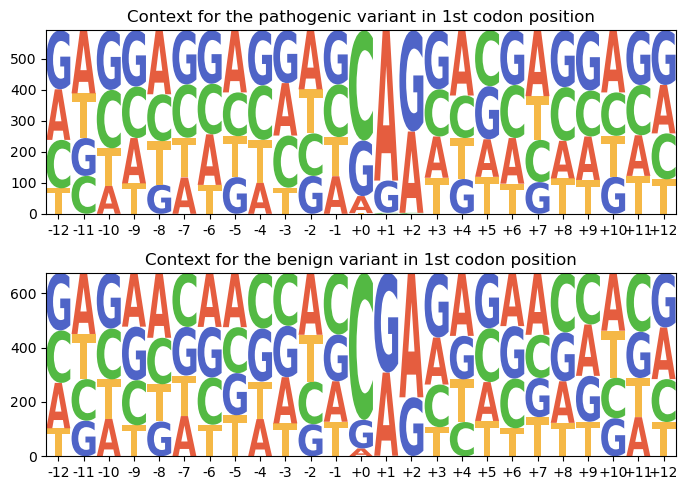

In [62]:
counts_mat_pat_1 = lm.alignment_to_matrix(filtered_context_pat_1)
counts_mat_ben_1 = lm.alignment_to_matrix(filtered_context_ben_1)

fig, axs = plt.subplots(2, 1, figsize=(7, 5))

pat_logo = lm.Logo(counts_mat_pat_1, color_scheme=custom_colors, ax=axs[0])
pat_logo.style_xticks()
pat_logo.ax.set_xticklabels('%+d'%x for x in range(-12, 13))
pat_logo.ax.set_title('Context for the pathogenic variant in 1st codon position')
pat_logo.draw()

ben_logo = lm.Logo(counts_mat_ben_1, color_scheme=custom_colors, ax=axs[1])
ben_logo.style_xticks()
ben_logo.ax.set_xticklabels('%+d'%x for x in range(-12, 13))
ben_logo.ax.set_title('Context for the benign variant in 1st codon position')
ben_logo.draw()

plt.tight_layout()
plt.savefig('images/1st_pos_context_nmd_escape_wo_in_clinvar.png', bbox_inches='tight')

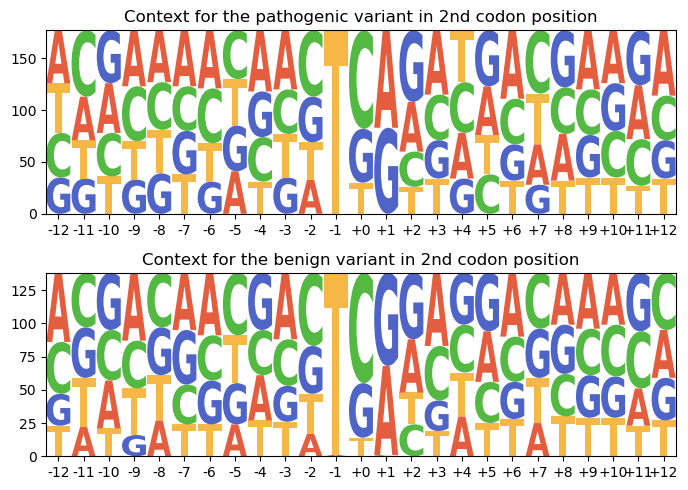

In [63]:
counts_mat_pat_2 = lm.alignment_to_matrix(filtered_context_pat_2)
counts_mat_ben_2 = lm.alignment_to_matrix(filtered_context_ben_2)

fig, axs = plt.subplots(2, 1, figsize=(7, 5))

pat_logo = lm.Logo(counts_mat_pat_2, color_scheme=custom_colors, ax=axs[0])
pat_logo.style_xticks()
pat_logo.ax.set_xticklabels('%+d'%x for x in range(-12, 13))
pat_logo.ax.set_title('Context for the pathogenic variant in 2nd codon position')
pat_logo.draw()

ben_logo = lm.Logo(counts_mat_ben_2, color_scheme=custom_colors, ax=axs[1])
ben_logo.style_xticks()
ben_logo.ax.set_xticklabels('%+d'%x for x in range(-12, 13))
ben_logo.ax.set_title('Context for the benign variant in 2nd codon position')
ben_logo.draw()

plt.tight_layout()
plt.savefig('images/2nd_pos_context_nmd_escape_wo_in_clinvar.png', bbox_inches='tight')

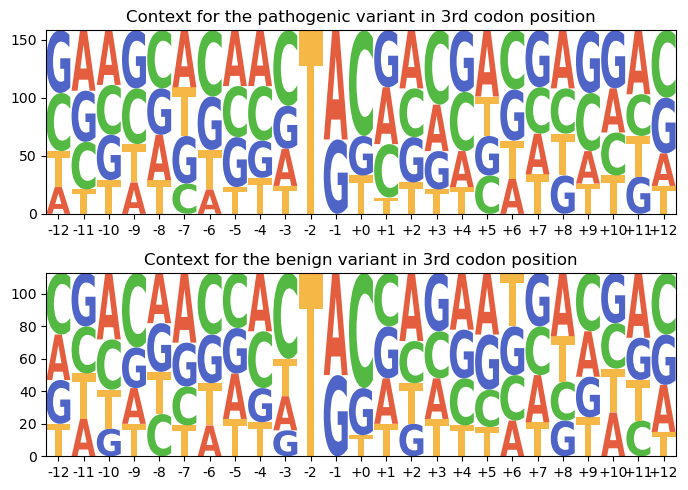

In [64]:
counts_mat_pat_3 = lm.alignment_to_matrix(filtered_context_pat_3)
counts_mat_ben_3 = lm.alignment_to_matrix(filtered_context_ben_3)

fig, axs = plt.subplots(2, 1, figsize=(7, 5))

pat_logo = lm.Logo(counts_mat_pat_3, color_scheme=custom_colors, ax=axs[0])
pat_logo.style_xticks()
pat_logo.ax.set_xticklabels('%+d'%x for x in range(-12, 13))
pat_logo.ax.set_title('Context for the pathogenic variant in 3rd codon position')
pat_logo.draw()

ben_logo = lm.Logo(counts_mat_ben_3, color_scheme=custom_colors, ax=axs[1])
ben_logo.style_xticks()
ben_logo.ax.set_xticklabels('%+d'%x for x in range(-12, 13))
ben_logo.ax.set_title('Context for the benign variant in 3rd codon position')
ben_logo.draw()

plt.tight_layout()
plt.savefig('images/3rd_pos_context_nmd_escape_wo_in_clinvar.png', bbox_inches='tight')

## 7. Statistical comparison of positions in contexts

Calculate chi-squares for each position when comparing two matrices (for pathogenic and benign contexts).

In [107]:
chi2_values_1, p_values_1 = calculate_chi2_p_values(filtered_context_ben_1, filtered_context_pat_1)
for i, (chi2, p_value) in enumerate(zip(chi2_values_1, p_values_1)):
    print(f"Position {i}: Chi-square = {chi2}, p-value = {p_value}")

Position 0: Chi-square = 1.994204438479549, p-value = 0.7547506131522739
Position 1: Chi-square = 0.9375025628156858, p-value = 0.9276925300780572
Position 2: Chi-square = 7.157084808635641, p-value = 0.41909974238282627
Position 3: Chi-square = 4.190248468106452, p-value = 0.5570662041590778
Position 4: Chi-square = 3.3705038653432657, p-value = 0.5887019990852077
Position 5: Chi-square = 1.6882265157484626, p-value = 0.7994430941718919
Position 6: Chi-square = 1.4506742112627333, p-value = 0.8258340133559243
Position 7: Chi-square = 3.260195671953139, p-value = 0.5887019990852077
Position 8: Chi-square = 3.2957376264945877, p-value = 0.5887019990852077
Position 9: Chi-square = 4.1395986495993675, p-value = 0.5570662041590778
Position 10: Chi-square = 2.1841542187833194, p-value = 0.7431614391918057
Position 11: Chi-square = 5.5540877535147075, p-value = 0.49367580783342485
Position 12: Chi-square = 62.643238262532535, p-value = 2.0010354693841136e-12
Position 13: Chi-square = 187.212

In [108]:
chi2_values_2, p_values_2 = calculate_chi2_p_values(filtered_context_ben_2, filtered_context_pat_2)
for i, (chi2, p_value) in enumerate(zip(chi2_values_2, p_values_2)):
    print(f"Position {i}: Chi-square = {chi2}, p-value = {p_value}")

Position 0: Chi-square = 6.3269075078770936, p-value = 0.8433761062535713
Position 1: Chi-square = 6.785763633014001, p-value = 0.8433761062535713
Position 2: Chi-square = 1.740615311424893, p-value = 1.0
Position 3: Chi-square = 4.527245845511825, p-value = 0.8433761062535713
Position 4: Chi-square = 3.342252744360122, p-value = 0.8433761062535713
Position 5: Chi-square = 1.9369493662753796, p-value = 1.0
Position 6: Chi-square = 2.986025613054435, p-value = 0.8433761062535713
Position 7: Chi-square = 2.9156085255937843, p-value = 0.8433761062535713
Position 8: Chi-square = 3.2814639514081607, p-value = 0.8433761062535713
Position 9: Chi-square = 1.2662595003764088, p-value = 1.0
Position 10: Chi-square = 2.35363376274339, p-value = 0.9660077584222574
Position 11: Chi-square = nan, p-value = 1.0
Position 12: Chi-square = nan, p-value = 1.0
Position 13: Chi-square = nan, p-value = 1.0
Position 14: Chi-square = 0.747917349219889, p-value = 1.0
Position 15: Chi-square = 3.258005334976327

In [109]:
chi2_values_3, p_values_3 = calculate_chi2_p_values(filtered_context_ben_3, filtered_context_pat_3)
for i, (chi2, p_value) in enumerate(zip(chi2_values_3, p_values_3)):
    print(f"Position {i}: Chi-square = {chi2}, p-value = {p_value}")

Position 0: Chi-square = 6.197673414406853, p-value = 0.5904234521322672
Position 1: Chi-square = 8.606899400961234, p-value = 0.4375094961272778
Position 2: Chi-square = 4.110609866576237, p-value = 0.6244132721960564
Position 3: Chi-square = 4.73294741628651, p-value = 0.5904234521322672
Position 4: Chi-square = 2.6872110352666088, p-value = 0.7872174865151185
Position 5: Chi-square = 4.68257713353022, p-value = 0.5904234521322672
Position 6: Chi-square = 0.8872266325890907, p-value = 1.0
Position 7: Chi-square = 2.3054675497476507, p-value = 0.7991785607816912
Position 8: Chi-square = 0.20994313746785725, p-value = 1.0
Position 9: Chi-square = 4.497062641024125, p-value = 0.5904234521322672
Position 10: Chi-square = nan, p-value = 1.0
Position 11: Chi-square = nan, p-value = 1.0
Position 12: Chi-square = nan, p-value = 1.0
Position 13: Chi-square = 5.163281222420515, p-value = 0.5904234521322672
Position 14: Chi-square = 3.273871438971499, p-value = 0.7175217515186948
Position 15: C

In [110]:
positions_list = [list(range(-12, 13)), list(range(-12, 13)), list(range(-12, 13))]
p_values_list = [p_values_1, p_values_2, p_values_3]

In [111]:
pvalues_to_replace = [2.0010354693841136e-12, 6.104237028740741e-39]

for i, arr in enumerate(p_values_list):
    for val in pvalues_to_replace:
        arr[arr == val] = 1.0

In [112]:
p_values_list

[array([0.75475061, 0.92769253, 0.41909974, 0.5570662 , 0.588702  ,
        0.79944309, 0.82583401, 0.588702  , 0.588702  , 0.5570662 ,
        0.74316144, 0.49367581, 1.        , 1.        , 1.        ,
        0.49367581, 0.42074639, 0.95506789, 0.65943687, 0.5570662 ,
        0.5570662 , 0.14898925, 0.74236265, 0.54421642, 0.94793957]),
 array([0.84337611, 0.84337611, 1.        , 0.84337611, 0.84337611,
        1.        , 0.84337611, 0.84337611, 0.84337611, 1.        ,
        0.96600776, 1.        , 1.        , 1.        , 1.        ,
        0.84337611, 0.84337611, 1.        , 1.        , 0.84337611,
        1.        , 1.        , 1.        , 0.84337611, 0.84337611]),
 array([0.59042345, 0.4375095 , 0.62441327, 0.59042345, 0.78721749,
        0.59042345, 1.        , 0.79917856, 1.        , 0.59042345,
        1.        , 1.        , 1.        , 0.59042345, 0.71752175,
        0.4375095 , 0.59042345, 0.71752175, 0.71752175, 1.        ,
        1.        , 0.59042345, 1.        , 

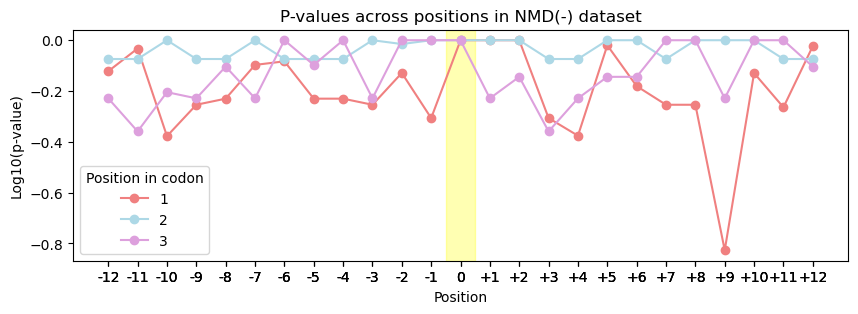

In [113]:
plt.figure(figsize=(10, 3))
#colors = ['#C8A2C8', '#B0E0E6', '#FFB6C1']
colors = ['lightcoral', 'lightblue', 'plum']

for positions, p_values, color in zip(positions_list, p_values_list, colors):
    plt.plot(positions, np.log10(p_values), marker='o', linestyle='-', color=color)

plt.title('P-values across positions in NMD(-) dataset')
plt.xlabel('Position')
plt.ylabel('Log10(p-value)')
plt.grid(False)
plt.legend(['1', '2', '3'], title='Position in codon')

all_positions = [pos for sublist in positions_list for pos in sublist]
plt.xticks(all_positions, [str(pos) if pos == 0 else f"{pos}" if pos < 0 else f"+{pos}" for pos in all_positions])

plt.axvspan(-0.5, 0.5, color='yellow', alpha=0.3)

plt.savefig('images/p_values_nmd_escape_plot_wo_in_clinvar.png')
plt.show()

In [114]:
# +9 это p-value = 0.14898924659167337

In [71]:
pat_nmd_escape_final[pat_nmd_escape_final['Codon_position'] == 1].head(5)

,CHROM,POS,ID,REF,ALT,AC,Consequence,IMPACT,SYMBOL,Gene,...,LoF_filter,LoF_flags,LoF_info,LOEUF,pext,NMD_escape,Context,Codon_position,Initial_Codon,Stop_Codon
2048,chr9,5921681,NaN,G,A,1,stop_gained,HIGH,KIAA2026,ENSG00000183354,...,NaN,NaN,PERCENTILE:0.683618504435995,0.336,0.732065,YES,ACTCCAACTAAACAGCAACAAGTAG,1,CAG,TAG
2047,chr9,5921675,NaN,G,A,1,stop_gained,HIGH,KIAA2026,ENSG00000183354,...,NaN,NaN,PERCENTILE:0.6845690747782,0.336,0.732065,YES,ACTAAACAGCAACAAGTAGATTATA,1,CAA,TAA
2057,chr9,5922227,rs1011885350,G,A,1,stop_gained,HIGH,KIAA2026,ENSG00000183354,...,NaN,NaN,PERCENTILE:0.59711660329531,0.336,0.732065,YES,AACTGTTTTGCACAACAGACTGCTG,1,CAA,TAA
1366,chr6,7582693,rs2113697854,G,T,1,stop_gained,HIGH,DSP,ENSG00000096696,...,NaN,NaN,PERCENTILE:0.630338904363974,0.260,0.999478,YES,CAGGTGGTACAGGAAAGAGAGAGCC,1,GAA,TAA
1375,chr6,7583287,NaN,C,T,1,stop_gained,HIGH,DSP,ENSG00000096696,...,NaN,NaN,PERCENTILE:0.699280408542247,0.260,0.999478,YES,GCTTCTGAAATCCAGCCATTCCTTC,1,CAG,TAG


In [72]:
pat_nmd_escape_final['Codon_position'].value_counts()

Codon_position
1    591
2    177
3    158
Name: count, dtype: int64

In [73]:
ben_nmd_escape_final['Codon_position'].value_counts()

Codon_position
1    675
2    138
3    113
Name: count, dtype: int64

## 8. Relationship between the significance of a variant and its position in a codon

In [74]:
pat_nmd_escape_final.loc[:, 'Significance'] = 'pathogenic'
ben_nmd_escape_final.loc[:, 'Significance'] = 'benign'

In [75]:
ben_nmd_escape_final

,CHROM,POS,ID,REF,ALT,AC,Consequence,IMPACT,SYMBOL,Gene,...,LoF_flags,LoF_info,LOEUF,pext,NMD_escape,Context,Codon_position,Initial_Codon,Stop_Codon,Significance
390,chr5,112841659,rs1554087174,C,A,2.0,stop_gained,HIGH,APC,ENSG00000134982,...,NaN,PERCENTILE:0.710853258321613,0.161,0.904855,YES,CAGTTTGTTTCTCAAGAAACAGTTC,2,TCA,TAA,benign
619,chr9,5919796,rs562646820,G,C,2.0,stop_gained,HIGH,KIAA2026,ENSG00000183354,...,NaN,PERCENTILE:0.982256020278834,0.336,0.732065,YES,CTAAGGTTTCTTCACTCTCTCCATC,2,TCA,TGA,benign
620,chr9,5919892,NaN,G,C,2.0,stop_gained,HIGH,KIAA2026,ENSG00000183354,...,NaN,PERCENTILE:0.967046894803549,0.336,0.732065,YES,CAAGTAGCACTTCAGTGTTTCATTT,2,TCA,TGA,benign
624,chr9,5922466,rs758532108,G,C,4.0,stop_gained,HIGH,KIAA2026,ENSG00000183354,...,NaN,PERCENTILE:0.559252217997465,0.336,0.732065,YES,TTACACCTTTATCAAATATAAGTAG,2,TCA,TGA,benign
621,chr9,5920046,rs754345617,G,A,9.0,stop_gained,HIGH,KIAA2026,ENSG00000183354,...,NaN,PERCENTILE:0.942648922686945,0.336,0.732065,YES,CATACATCACCACAACTCATAAACA,1,CAA,TAA,benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14,chr1,24350118,rs1390189012,C,T,4.0,stop_gained,HIGH,GRHL3,ENSG00000158055,...,NaN,PERCENTILE:0.934217799889442,0.158,0.983307,YES,AAGAAATGCAAGCGAGGAATCTTAG,1,CGA,TGA,benign
13,chr1,23083263,NaN,C,T,12.0,stop_gained,HIGH,KDM1A,ENSG00000004487,...,NaN,PERCENTILE:0.961611554541999,0.276,0.815216,YES,CTGAGTGGGCTGCGAGAAGCGGGAA,1,CGA,TGA,benign
8,chr1,17409101,rs2075397397,G,A,2.0,stop_gained,HIGH,RCC2,ENSG00000179051,...,NaN,PERCENTILE:0.992989165073295,0.334,0.999379,YES,GAATACAACCCCCGAACCCTCTGAT,1,CGA,TGA,benign
7,chr1,16251562,rs532744461,G,T,57.0,stop_gained,HIGH,FBXO42,ENSG00000037637,...,NaN,PERCENTILE:0.585886722376973,0.274,0.997337,YES,GGCAGACTCCTTCAGGTTCCCGGGA,2,TCA,TAA,benign


In [76]:
all_nmd_escape_final = pd.concat([pat_nmd_escape_final, ben_nmd_escape_final], ignore_index=True)

In [77]:
all_nmd_escape_final.to_csv('data/all_nmd_escape_final_wo_in_clinvar.csv', index=False)

In [78]:
all_nmd_escape_final

,CHROM,POS,ID,REF,ALT,AC,Consequence,IMPACT,SYMBOL,Gene,...,LoF_flags,LoF_info,LOEUF,pext,NMD_escape,Context,Codon_position,Initial_Codon,Stop_Codon,Significance
0,chr5,112839436,rs1765536013,C,A,1.0,stop_gained,HIGH,APC,ENSG00000134982,...,NaN,PERCENTILE:0.450304735114862,0.161,0.904855,YES,TATCATCTTTGTCATCAGCTGAAGA,2,TCA,TAA,pathogenic
1,chr9,5922160,NaN,G,T,1.0,stop_gained,HIGH,KIAA2026,ENSG00000183354,...,NaN,PERCENTILE:0.607731305449937,0.336,0.732065,YES,GAGATTCACAGTCAATTCTTGTTAG,2,TCA,TAA,pathogenic
2,chr9,5921681,NaN,G,A,1.0,stop_gained,HIGH,KIAA2026,ENSG00000183354,...,NaN,PERCENTILE:0.683618504435995,0.336,0.732065,YES,ACTCCAACTAAACAGCAACAAGTAG,1,CAG,TAG,pathogenic
3,chr9,5919982,NaN,G,C,1.0,stop_gained,HIGH,KIAA2026,ENSG00000183354,...,NaN,PERCENTILE:0.952788339670469,0.336,0.732065,YES,TATCACTGACTTCAGTAATTAAGTC,2,TCA,TGA,pathogenic
4,chr9,5921675,NaN,G,A,1.0,stop_gained,HIGH,KIAA2026,ENSG00000183354,...,NaN,PERCENTILE:0.6845690747782,0.336,0.732065,YES,ACTAAACAGCAACAAGTAGATTATA,1,CAA,TAA,pathogenic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1847,chr1,24350118,rs1390189012,C,T,4.0,stop_gained,HIGH,GRHL3,ENSG00000158055,...,NaN,PERCENTILE:0.934217799889442,0.158,0.983307,YES,AAGAAATGCAAGCGAGGAATCTTAG,1,CGA,TGA,benign
1848,chr1,23083263,NaN,C,T,12.0,stop_gained,HIGH,KDM1A,ENSG00000004487,...,NaN,PERCENTILE:0.961611554541999,0.276,0.815216,YES,CTGAGTGGGCTGCGAGAAGCGGGAA,1,CGA,TGA,benign
1849,chr1,17409101,rs2075397397,G,A,2.0,stop_gained,HIGH,RCC2,ENSG00000179051,...,NaN,PERCENTILE:0.992989165073295,0.334,0.999379,YES,GAATACAACCCCCGAACCCTCTGAT,1,CGA,TGA,benign
1850,chr1,16251562,rs532744461,G,T,57.0,stop_gained,HIGH,FBXO42,ENSG00000037637,...,NaN,PERCENTILE:0.585886722376973,0.274,0.997337,YES,GGCAGACTCCTTCAGGTTCCCGGGA,2,TCA,TAA,benign


In [79]:
cross_tab_escape = pd.crosstab(all_nmd_escape_final['Significance'], all_nmd_escape_final['Codon_position'])
print(cross_tab_escape)

Codon_position    1    2    3
Significance                 
benign          675  138  113
pathogenic      591  177  158


In [80]:
cross_tab_escape_perc = pd.crosstab(
    all_nmd_escape_final['Significance'], 
    all_nmd_escape_final['Codon_position'], 
    normalize='index'  # Делит на сумму в каждой строке
) * 100
print(cross_tab_escape_perc)

Codon_position          1          2          3
Significance                                   
benign          72.894168  14.902808  12.203024
pathogenic      63.822894  19.114471  17.062635


In [81]:
chi2_escape, p_value_escape, _, _ = chi2_contingency(cross_tab_escape)
print(f"Chi-squared value: {chi2_escape}")
print(f"P-value: {p_value_escape}")

Chi-squared value: 17.874355867458473
P-value: 0.0001314113689812517


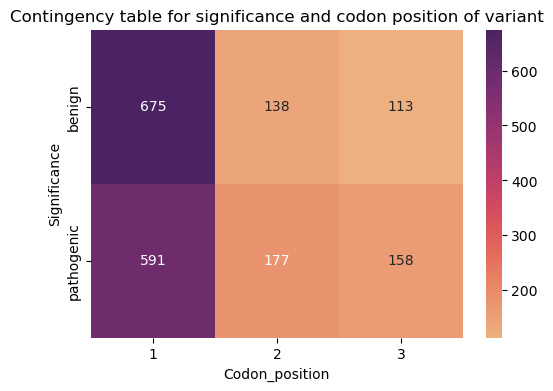

In [82]:
plt.figure(figsize=(6, 4))
sns.heatmap(cross_tab_escape, annot=True, cmap='flare', fmt='d', cbar=True)
plt.title('Contingency table for significance and codon position of variant')
plt.xlabel('Codon_position')
plt.ylabel('Significance')
plt.show()


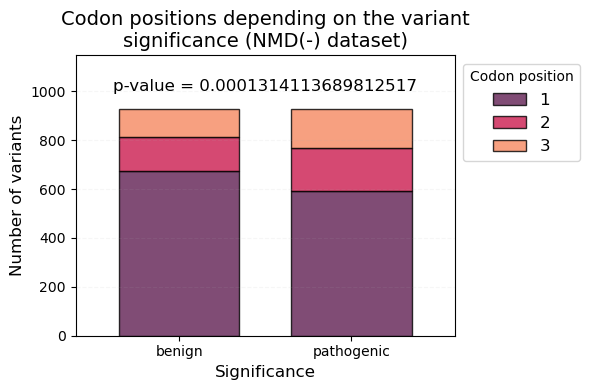

In [83]:
palette = sns.color_palette("rocket", len(cross_tab_escape.columns))

ax = cross_tab_escape.plot(kind='bar', stacked=True, alpha=0.8, edgecolor='black', linewidth=1, width=0.7, color=palette, figsize=(6, 4))

plt.title('Codon positions depending on the variant\nsignificance (NMD(-) dataset)', fontsize=14)
plt.xlabel('Significance', fontsize=12)
plt.ylabel('Number of variants', fontsize=12)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Codon position', fontsize=12, bbox_to_anchor=(1, 1), loc='upper left')
plt.ylim(top=cross_tab_escape.max().max() * 1.7)
plt.text(0.5, 1000, f'p-value = {p_value_escape}', fontsize=12, ha='center')
plt.grid(True, axis='y', linestyle='--', alpha=0.1)
plt.tight_layout()

plt.savefig('images/codon_positions_hist_escape_wo_in_clinvar.png', dpi=300)

plt.show()